[![img/pythonista.png](img/pythonista.png)](https://www.pythonista.io)

# Objetos de *Seaborn*.

Aún cuando las funciones *Seaborn* son muy populares y fáciles de desarrollar, tienen ciertas desventajas con respecto a otras soluciones basadas en gramáticas de gráficas. A partir de la versión 0.12, *Seaborn* cuenta con una biblioteca de objetos que se apega a dicha gramática.


<img src="img/grammar_of_graphics.png">

Por convención, la biblioteca de objetos de seaborn ```seaborn.objects``` es importada como ```so```. En adelante, se seguirá dicha convención.

https://seaborn.pydata.org/tutorial/objects_interface.html

**NOTA:** Debido a que los objetos de *Seaborn* son una adición muy reciente, aún tienen funcionalidades limitadas en comparación con las funciones.

* La siguiente celda importa `seaborn` con el alias `sns` y el submódulo `objects` con el alias `so`.

In [1]:
import seaborn as sns
from seaborn import objects as so

## La clase ```so.Plot```.

Los componentes principales de este tipo de visualizaciones son los objetos instanciados de la clase ```so.Plot```.

```
so.Plot(data=<datos>, x=<x>, y=<y>, <args>)
```

Donde:

* ```<datos>``` es un *dataset* compatible con un *dataframe* de *Pandas*.
* ```<x>``` es el identificador de la columna del ```<dataset>``` que se utilizará para el eje de las $x$ en caso de que se requiera.
* ```<y>``` es el identificador de la columna del ```<dataset>``` que se utilizará para el eje de las $y$ en caso de que se requiera.


Los objetos instanciados de ```so.Plot``` cuentan con varios métodos y atributos que permiten cumplir con las funcionalidades de las capas:

* Datos.
* Estética.
* Escala.
* Facetas.

https://seaborn.pydata.org/generated/seaborn.objects.Plot.html

## Métodos en cascada.

Los métodos de los objetos instanciados de ```so.Plot``` también regresan objetos instanciados de ```so.Plot```, por lo que es posible aplicar métodos en cascada.

### El método ```so.Plot.add()```.

Este método permite añadir capas de representación a los objetos de tipo ```so.Plot```, definiendo principalmente los objetos geométricos (*marks*) y las transformaciones estadísticas (*stats*).

```
<plot>.add(<mark>(), <stat>(), <args>)
```

Donde:

* ```<mark>``` es una clase de marca de ```seaborn.objects``` (p. ej. ```so.Dot```, ```so.Bar```, ```so.Line```).
* ```<stat>``` es una transformación estadística opcional (p. ej. ```so.Hist```, ```so.KDE```, ```so.Count```).
* ```<args>``` son argumentos adicionales que se pasan a la marca o a la transformación estadística.

https://seaborn.pydata.org/generated/seaborn.objects.Plot.add.html

**Ejemplo:**

* La siguiente celda carga el conjunto de datos "iris" y lo asigna a la variable `dataset`, mostrando su contenido.

In [2]:
dataset = sns.load_dataset("iris")
dataset

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


* La siguiente celda inicializa un objeto `so.Plot` asignando las variables para los ejes $x$ e $y$, pero sin definir ninguna representación gráfica aún.

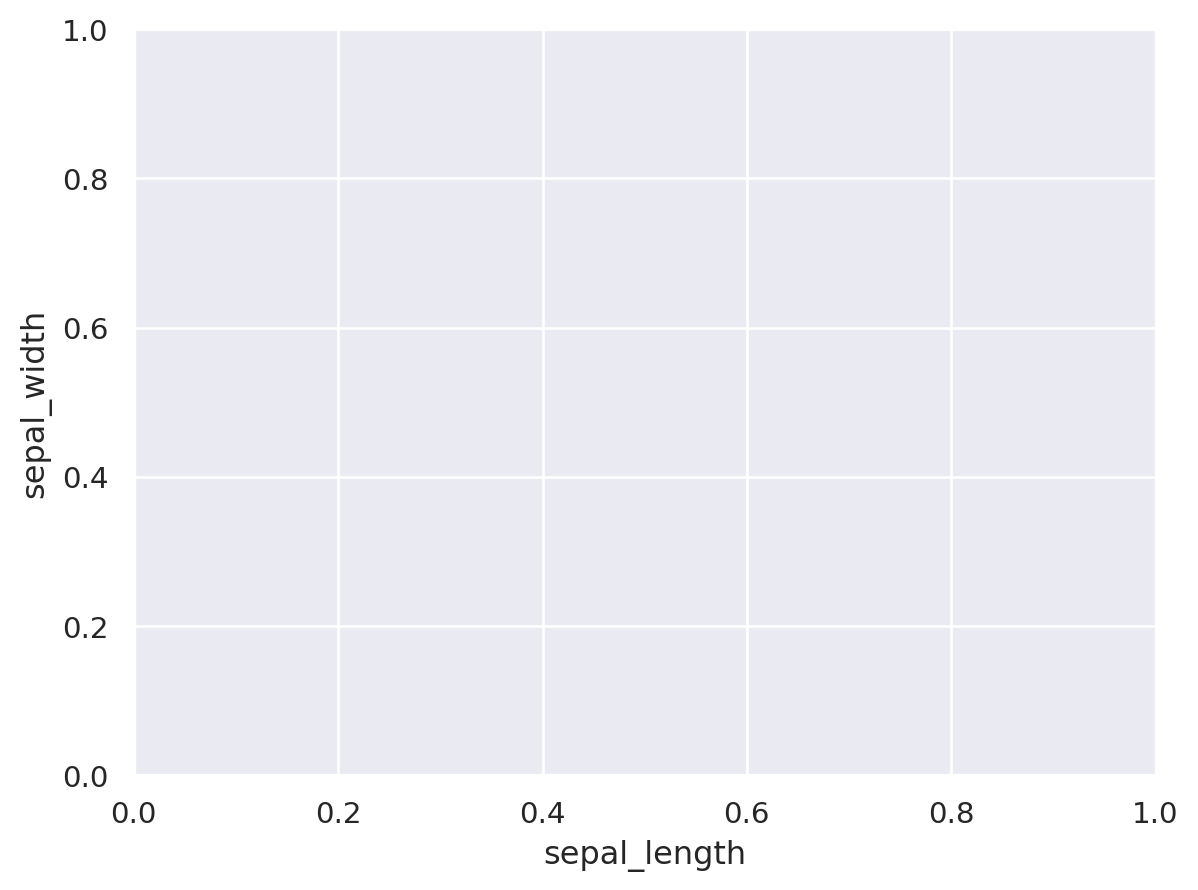

In [3]:
so.Plot(data=dataset,
        x="sepal_length",
        y="sepal_width")

* La siguiente celda añade una capa de puntos (`so.Dot`) al gráfico para visualizar los datos.

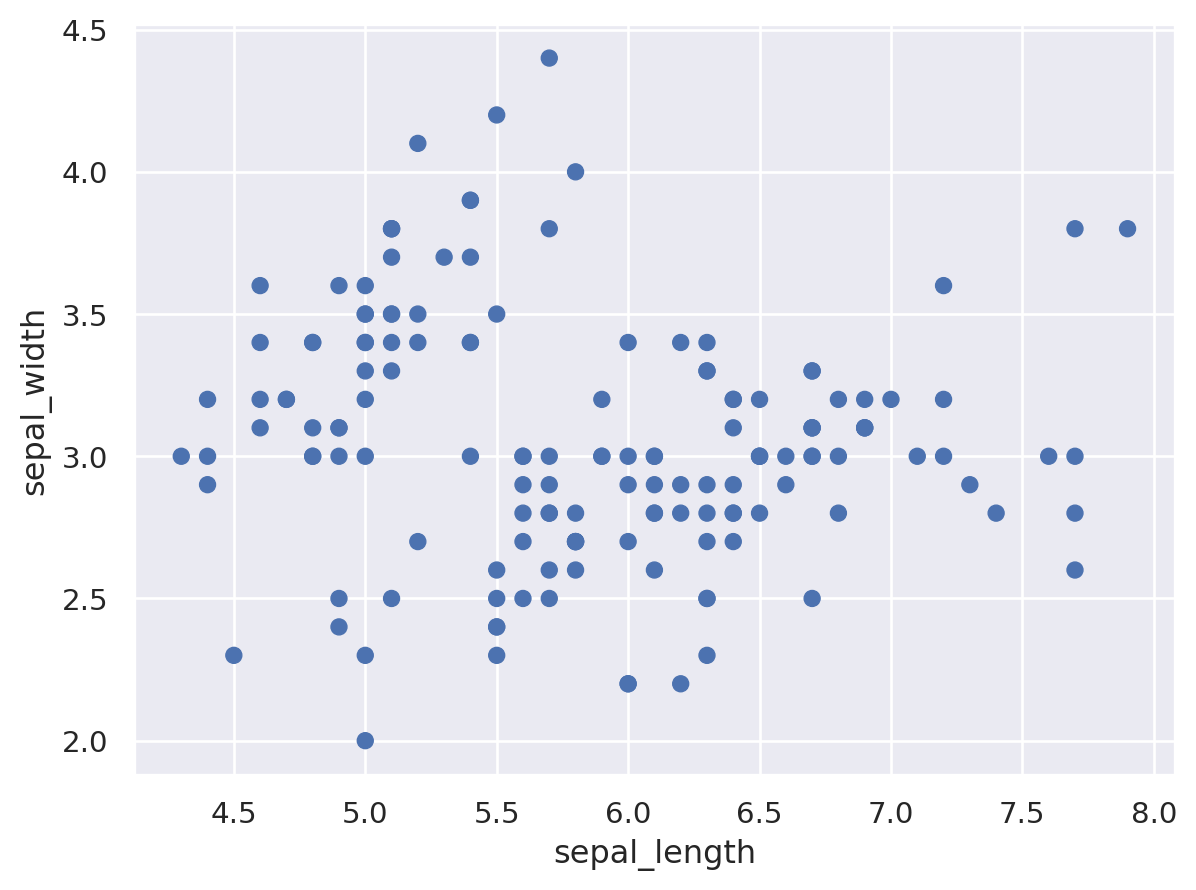

In [4]:
(so.Plot(data=dataset,
         x="sepal_length",
         y="sepal_width")
 .add(so.Dot()))

* La siguiente celda asigna la variable `"species"` al color de los puntos, permitiendo diferenciar las categorías.

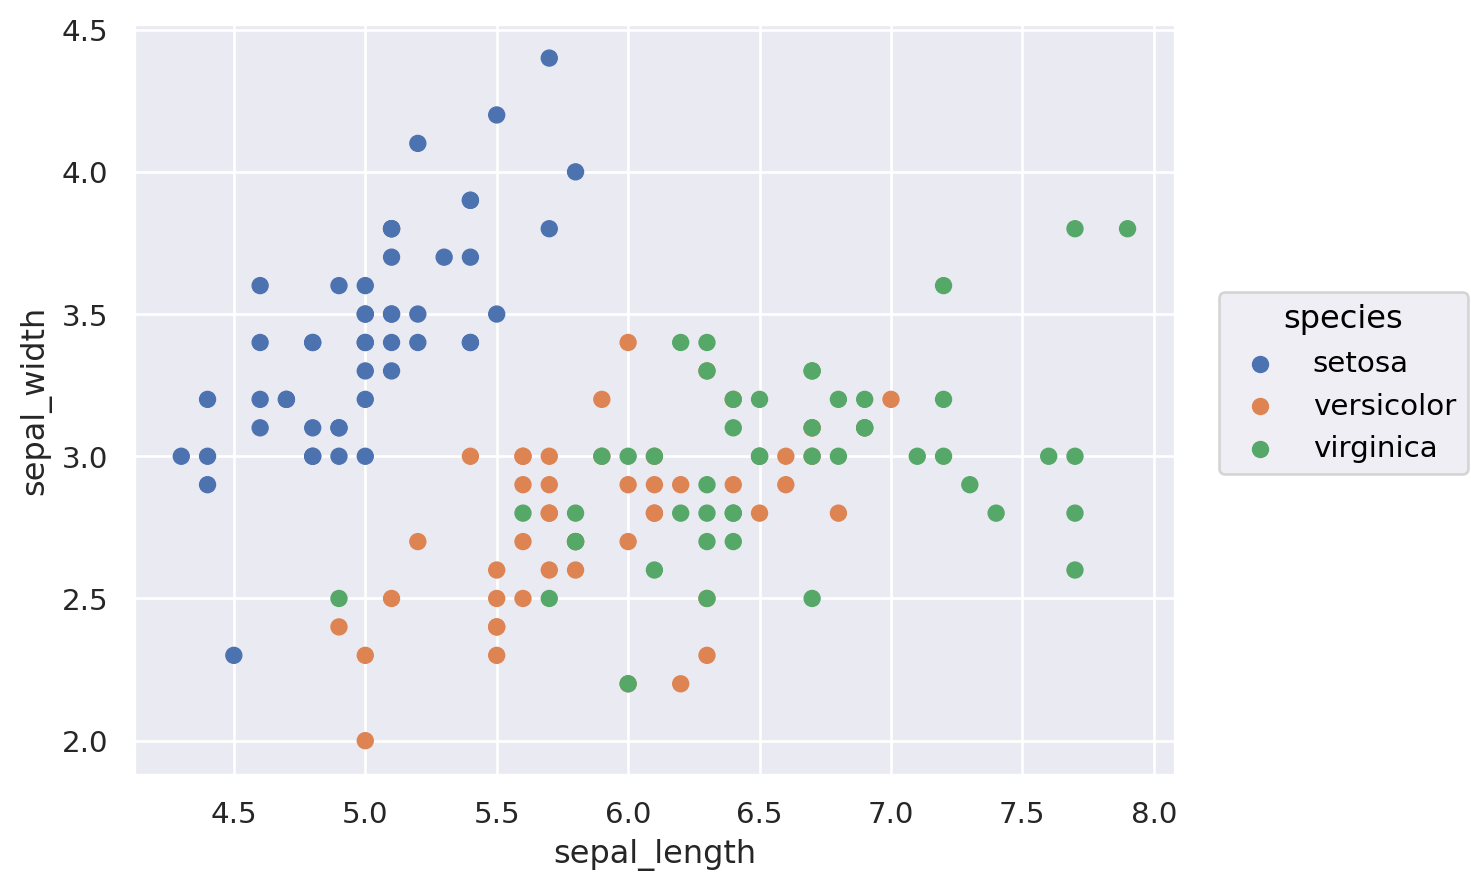

In [5]:
(so.Plot(data=dataset,
         x="sepal_length",
         y="sepal_width",
         color="species")
 .add(so.Dot()))

* La siguiente celda utiliza el método `.facet()` para crear subgráficos separados por la categoría `"species"`.

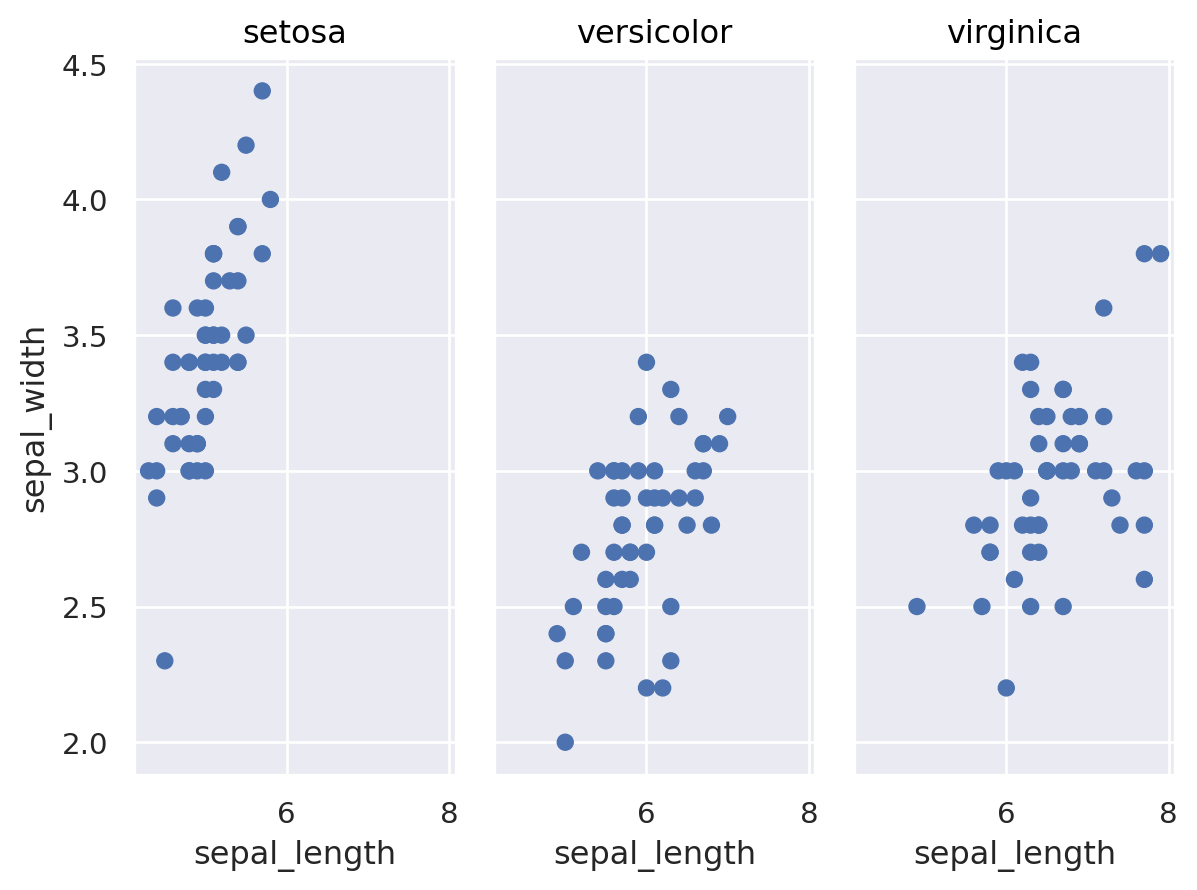

In [6]:
(so.Plot(data=dataset,
         x='sepal_length',
         y='sepal_width')
 .facet('species')
 .add(so.Dot()))

* La siguiente celda combina una marca de barra (`so.Bar`) con una transformación estadística de histograma (`so.Hist`), creando histogramas facetados por especie.

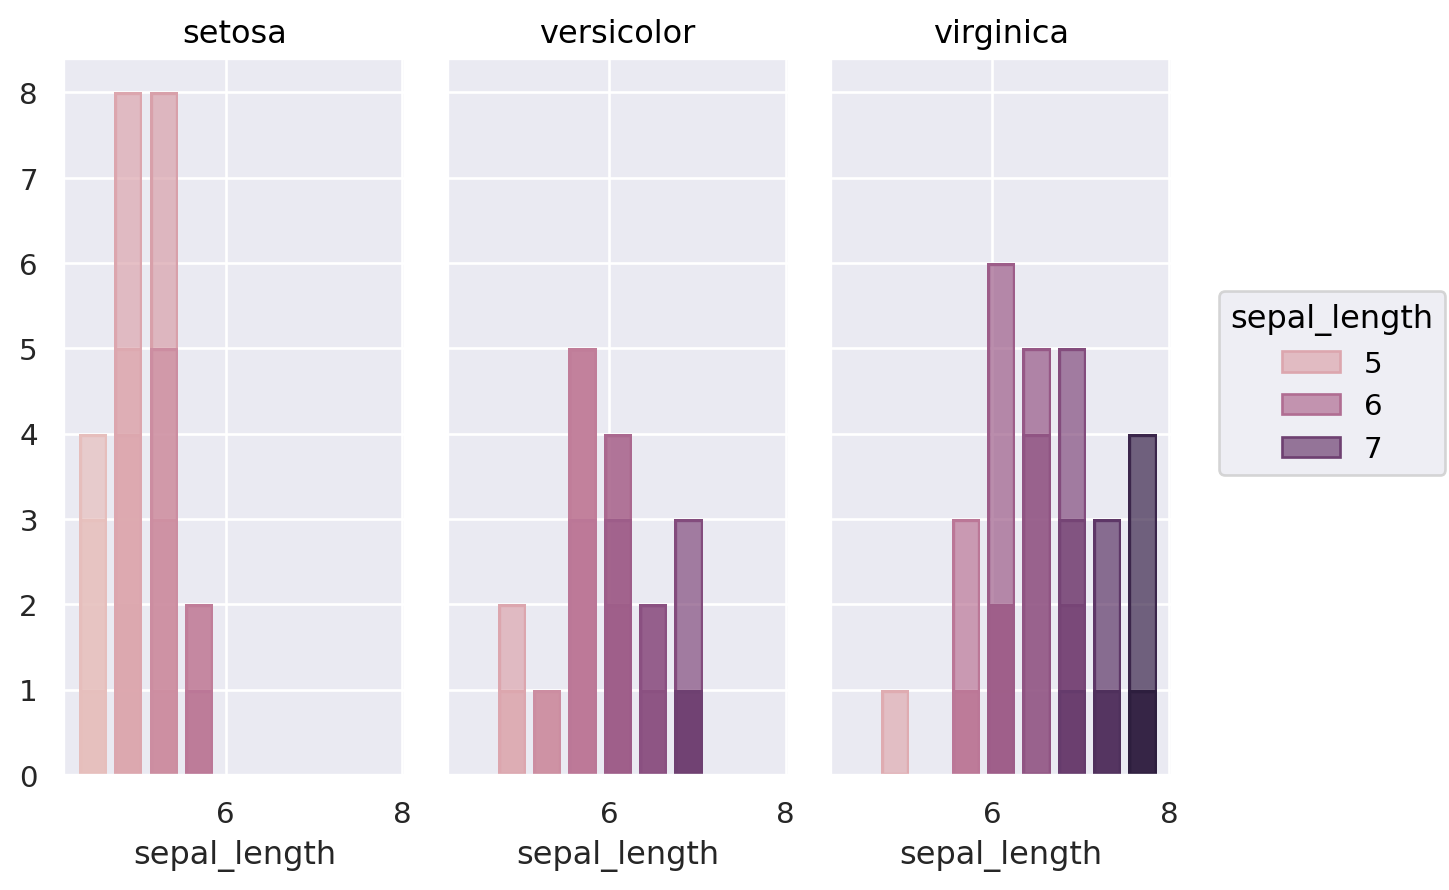

In [7]:
(so.Plot(data=dataset,
         x='sepal_length',
         color='sepal_length')
 .facet('species')
 .add(so.Bar(),
      so.Hist()))

* La siguiente celda aplica una escala logarítmica al eje $y$ utilizando el método `.scale()`.

Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.
Ill-defined clip_path detected. Returning None.


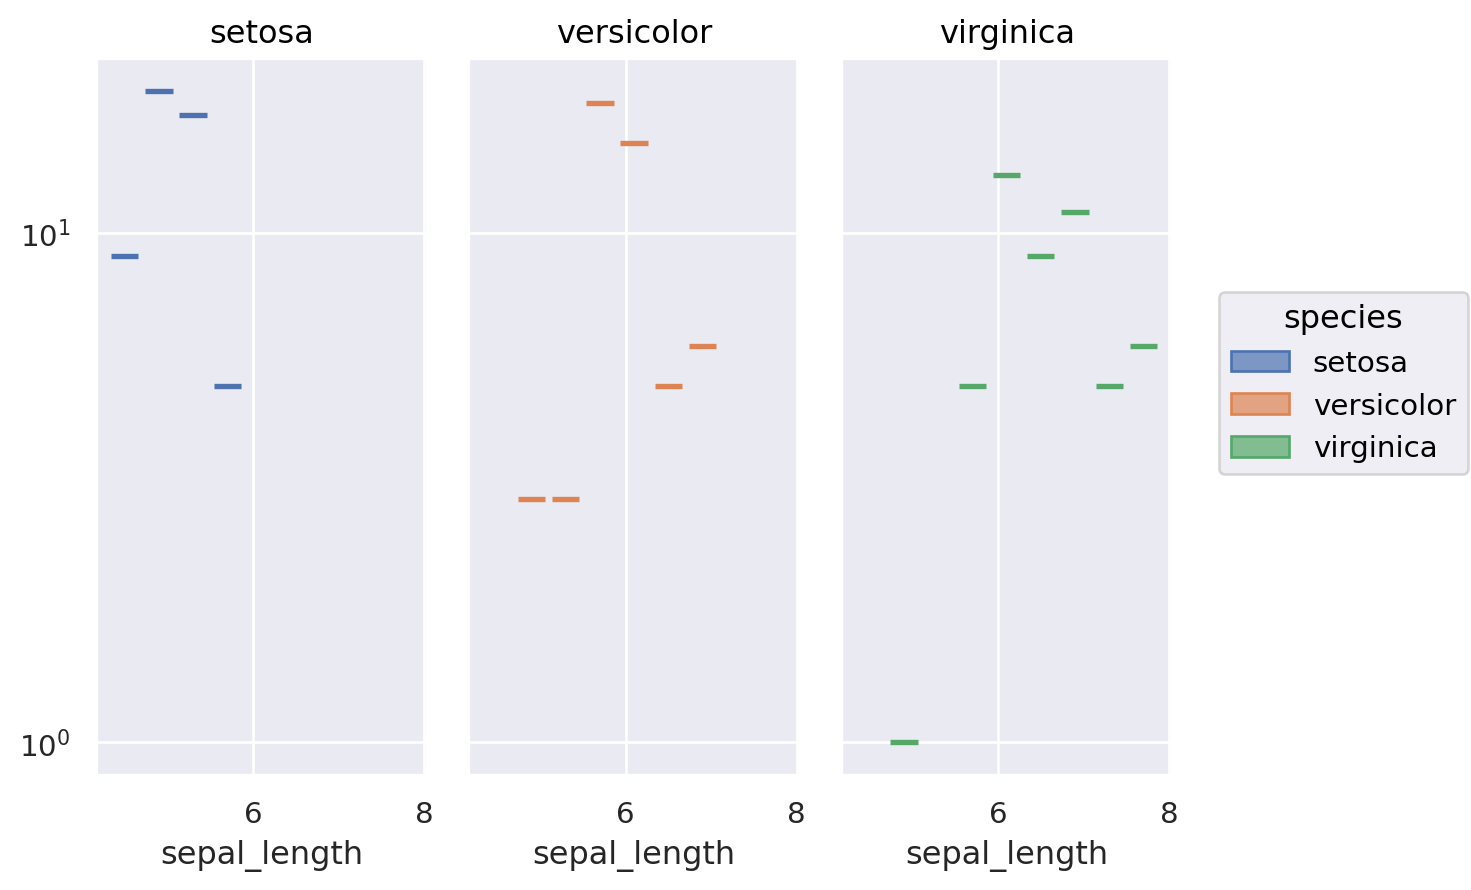

In [8]:
(so.Plot(data=dataset,
         x='sepal_length',
         color='species')
 .facet('species')
 .add(so.Bar(),
      so.Hist())
 .scale(y="log"))

### Combinación de capas.

Es posible añadir múltiples capas a un mismo gráfico utilizando llamadas sucesivas al método `.add()`.

* La siguiente celda muestra cómo combinar múltiples capas, añadiendo una estimación de densidad de kernel (KDE) representada como área y línea.

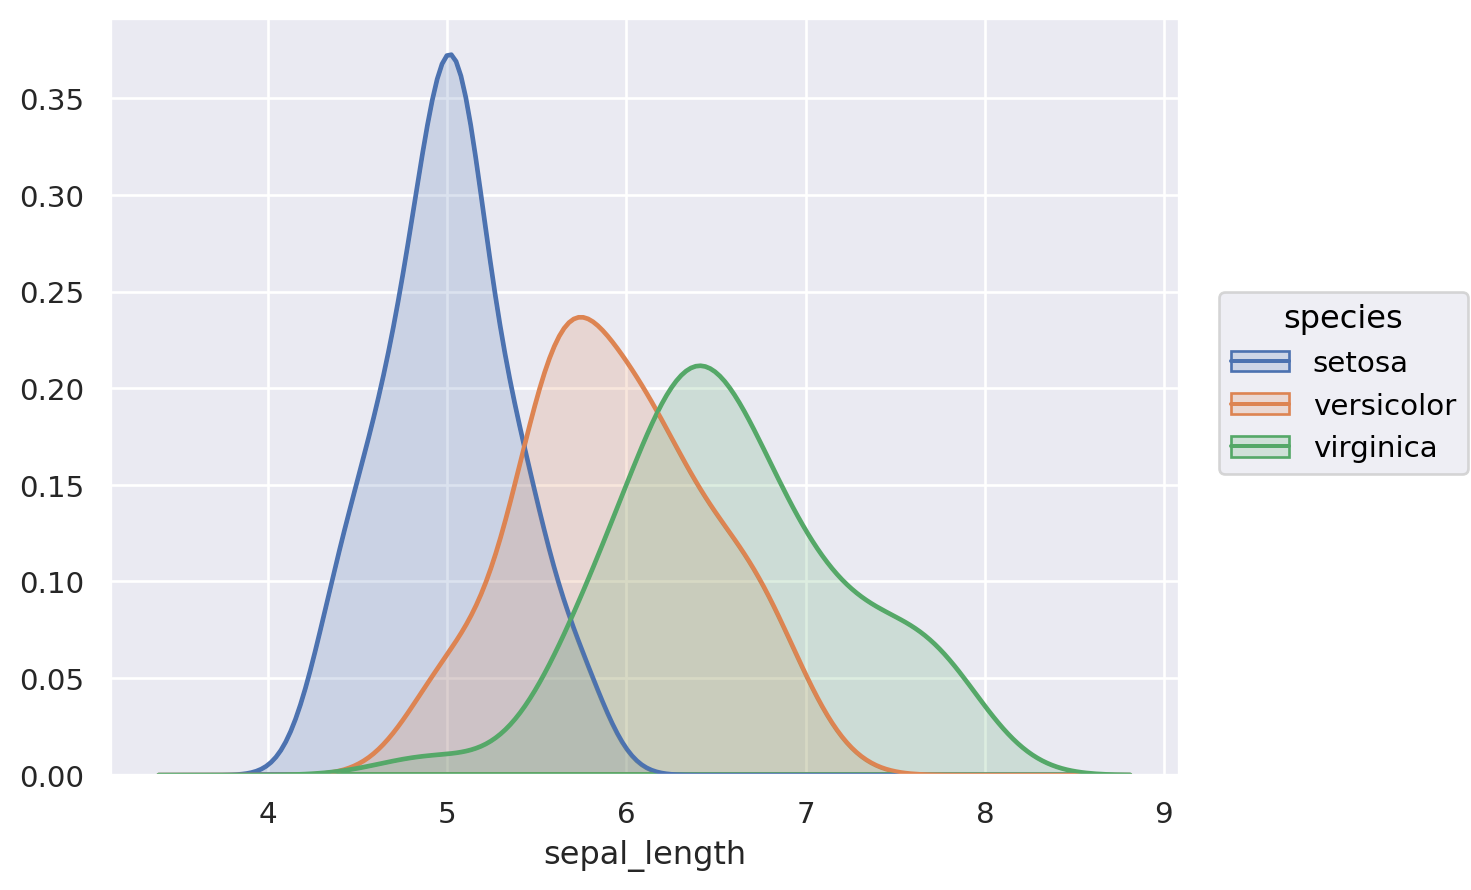

In [9]:
(so.Plot(data=dataset,
         x="sepal_length",
         color="species")
 .add(so.Area(),
      so.KDE())
 .add(so.Line(),
      so.KDE()))

## Marcas (*Marks*).

Las marcas definen la forma geométrica con la que se representan los datos. Las principales marcas disponibles en `seaborn.objects` son:

| Marca | Descripción |
|-------|-------------|
| `so.Dot` | Punto individual |
| `so.Dots` | Puntos con tamaño variable |
| `so.Bar` | Barra por cada fila del *dataset* |
| `so.Bars` | Barras para distribuciones estadísticas |
| `so.Line` | Línea con puntos ordenados por $x$ |
| `so.Lines` | Líneas por grupo |
| `so.Path` | Línea en el orden original de los datos |
| `so.Range` | Segmentos de intervalo |
| `so.Dash` | Guiones horizontales |

https://seaborn.pydata.org/api.html#marks

### `so.Dots`.

Similar a `so.Dot`, la marca `so.Dots` permite codificar una variable adicional mediante el parámetro estético `pointsize`, que controla el tamaño de cada punto. Es útil para representar tres variables simultáneamente en un diagrama de dispersión.

```
so.Plot(data=<dataset>, x=<x>, y=<y>, pointsize=<col>).add(so.Dots())
```

Donde:
* `<dataset>` es el conjunto de datos que contiene las columnas a utilizar.
* `<x>` es la columna que se asignará al eje $x$.
* `<y>` es la columna que se asignará al eje $y$.
* `<col>` es la columna numérica cuyo valor determinará el tamaño de cada punto.

https://seaborn.pydata.org/generated/seaborn.objects.Dots.html

* La siguiente celda crea un diagrama de dispersión con `so.Dots`, codificando la longitud del pétalo en el tamaño de cada punto mediante el parámetro estético `pointsize`.

In [ ]:
(so.Plot(data=dataset,
         x="sepal_length",
         y="sepal_width",
         color="species",
         pointsize="petal_length")
 .add(so.Dots()))

### `so.Bars`.

A diferencia de `so.Bar`, que dibuja una barra por cada fila del *dataset*, `so.Bars` está diseñado para usarse junto con transformaciones estadísticas como `so.Hist`. Gestiona automáticamente el ancho de las barras según los intervalos calculados.
```
so.Plot(data=<dataset>, x=<x_column>).add(
    so.Bars(), so.Hist())
```
Donde:
* `<dataset>` es el conjunto de datos que contiene la columna a utilizar.
* `<x_column>` es la columna que se asignará al eje $x$ para calcular el histograma.


https://seaborn.pydata.org/generated/seaborn.objects.Bars.html

* La siguiente celda muestra un ejemplo de cómo utilizar `so.Bars` junto con `so.Hist` para crear un histograma de la longitud del sépalo (`sepal_length`) por especie del conjunto de datos "iris".

In [ ]:
(so.Plot(data=dataset,
         x="sepal_length",
         color="species")
 .add(so.Bars(), so.Hist(binwidth=0.3)))

### `so.Path`.

La marca `so.Path` conecta los puntos en el orden en que aparecen en el *dataset*, sin reordenarlos por el eje $x$. Es útil para representar trayectorias o series temporales donde el orden original de los datos es significativo.

```
so.Plot(data=<dataset>, x=<x_column>, y=<y_column>).add(
    so.Path())
```
Donde:
* `<dataset>` es el conjunto de datos que contiene las columnas a utilizar.
* `<x_column>` es la columna que se asignará al eje $x$.
* `<y_column>` es la columna que se asignará al eje $y$.

https://seaborn.pydata.org/generated/seaborn.objects.Path.html

* La siguiente celda muestra un ejemplo de cómo utilizar `so.Path` para conectar los puntos de un gráfico de dispersión del ancho del sépalo (`sepal_width`) frente a la longitud del sépalo (`sepal_length`) del conjunto de datos "iris", manteniendo el orden original de las filas.

In [ ]:
flights = sns.load_dataset("flights")

(so.Plot(data=flights.query("month == 'Jan'"),
         x="year",
         y="passengers")
 .add(so.Path()))

## Transformaciones estadísticas y de movimiento.

Las transformaciones modifican los datos antes de dibujarlos. Se dividen en dos tipos:

* **Estadísticas** (`so.Hist`, `so.KDE`, `so.Count`, `so.Agg`): calculan resúmenes o agregaciones sobre los datos.
* **Movimientos** (`so.Dodge`, `so.Stack`, `so.Jitter`, `so.Shift`): reposicionan los elementos sin alterar sus valores.

https://seaborn.pydata.org/api.html#transforms

### `so.Count`.

La transformación `so.Count` cuenta el número de observaciones en cada categoría y pasa el resultado como la altura de la barra u otro canal geométrico.

```
so.Plot(data=<dataset>, x=<x_column>).add(
    so.Bar(), so.Count())
```
Donde:
* `<dataset>` es el conjunto de datos que contiene la columna a utilizar.
* `<x_column>` es la columna que se asignará al eje $x$ para contar las observaciones por categoría.

https://seaborn.pydata.org/generated/seaborn.objects.Count.html

* La siguiente celda carga el conjunto de datos "tips" y muestra un ejemplo de cómo utilizar `so.Count` junto con `so.Bar` para crear un diagrama de barras que cuenta las observaciones por día (`day`) y sexo (`sex`).

In [ ]:
tips = sns.load_dataset("tips")

(so.Plot(data=tips,
         x="day",
         color="sex")
 .add(so.Bar(), so.Count()))

### `so.Dodge`.

El movimiento `so.Dodge` separa lateralmente los elementos que se solaparían, permitiendo comparar grupos dentro de una misma categoría.

https://seaborn.pydata.org/generated/seaborn.objects.Dodge.html

* La siguiente celda muestra un ejemplo de cómo utilizar `so.Dodge` para separar lateralmente las barras de cada sexo (`sex`) dentro de cada día (`day`) del conjunto de datos "tips".

In [ ]:
(so.Plot(data=tips,
         x="day",
         color="sex")
 .add(so.Bar(), so.Count(), so.Dodge()))

### `so.Stack`.

El movimiento `so.Stack` apila los valores de los diferentes grupos a lo largo del eje de respuesta, mostrando tanto los valores individuales como el total acumulado.

```
so.Plot(data=<dataset>, x=<x>, color=<grupo>).add(so.Bar(), so.Count(), so.Stack())
```

Donde:
* `<dataset>` es el conjunto de datos que contiene las columnas a utilizar.
* `<x>` es la columna categórica que se asignará al eje $x$.
* `<grupo>` es la columna que se utilizará para diferenciar los grupos por color.

https://seaborn.pydata.org/generated/seaborn.objects.Stack.html

* La siguiente celda muestra un ejemplo de cómo utilizar `so.Stack` junto con `so.Bar` y `so.Count` para apilar las barras por sexo (`sex`) dentro de cada día (`day`) del conjunto de datos "tips".

In [ ]:
(so.Plot(data=tips,
         x="day",
         color="sex")
 .add(so.Bar(), so.Count(), so.Stack()))

### `so.Jitter`.

El movimiento `so.Jitter` desplaza los puntos de forma aleatoria para reducir el solapamiento en datos categóricos. El parámetro `width` controla la amplitud del desplazamiento horizontal.
```
so.Plot(data=<dataset>, x=<x_column>, y=<y_column>).add(
    so.Dot(), so.Jitter(width=<jitter_width>))
```
Donde:
* `<dataset>` es el conjunto de datos que contiene las columnas a utilizar.
* `<x_column>` es la columna que se asignará al eje $x$.
* `<y_column>` es la columna que se asignará al eje $y$.
* `<jitter_width>` es un valor numérico que determina la cantidad de desplazamiento horizontal aplicado a los puntos para reducir el solapamiento.

https://seaborn.pydata.org/generated/seaborn.objects.Jitter.html

* La siguiente celda muestra un ejemplo de cómo utilizar `so.Jitter` para desplazar aleatoriamente los puntos y reducir el solapamiento en los datos de longitud del sépalo (`sepal_length`) por especie del conjunto de datos "iris".

In [ ]:
(so.Plot(data=dataset,
         x="species",
         y="sepal_length",
         color="species")
 .add(so.Dot(), so.Jitter(width=0.3)))

## Métodos de configuración de `so.Plot`.

Además de `.add()`, `.facet()` y `.scale()`, los objetos de `so.Plot` cuentan con otros métodos para controlar la presentación del gráfico.

https://seaborn.pydata.org/generated/seaborn.objects.Plot.html

### El método `.label()`.

El método `.label()` permite personalizar el título de la figura y las etiquetas de los ejes y de la leyenda.

```
so.Plot(data=<dataset>, x=<x_column>, y=<y_column>, color=<group_column>).add(
    so.Bars(), so.Hist(), so.Stack()).label(
        title=<title>, x=<x_label>, y=<y_label>, color=<legend_title>)
```
Donde:
* `<dataset>` es el conjunto de datos que contiene las columnas a utilizar.
* `<x_column>` es la columna que se asignará al eje $x$.
* `<y_column>` es la columna que se asignará al eje $y$.
* `<group_column>` es la columna que se utilizará para diferenciar los grupos por color.
* `<title>` es una cadena de texto que se utilizará como título del gráfico.
* `<x_label>` es una cadena de texto que se utilizará como etiqueta del eje $x$.
* `<y_label>` es una cadena de texto que se utilizará como etiqueta del eje $y$.
* `<legend_title>` es una cadena de texto que se utilizará como título de la leyenda para el canal de color.


https://seaborn.pydata.org/generated/seaborn.objects.Plot.label.html

* La siguiente celda muestra un ejemplo de cómo utilizar `.label()` para añadir un título y etiquetas descriptivas a los ejes y a la leyenda de un diagrama de dispersión del conjunto de datos "iris".

In [ ]:
(so.Plot(data=dataset,
         x="sepal_length",
         y="sepal_width",
         color="species")
 .add(so.Dot())
 .label(title="Dimensiones del sépalo por especie",
        x="Longitud del sépalo (cm)",
        y="Ancho del sépalo (cm)",
        color="Especie"))

### El método `.limit()`.

El método `.limit()` establece los límites de los ejes $x$ e $y$.

```
so.Plot(data=<dataset>, x=<x_column>, y=<y_column>).add(
    <mark>()).limit(x=(<x_min>, <x_max>), y=(<y_min>, <y_max>))
```
Donde:
* `<x_min>` es el valor mínimo del eje $x$.
* `<x_max>` es el valor máximo del eje $x$.
* `<y_min>` es el valor mínimo del eje $y$.
* `<y_max>` es el valor máximo del eje $y$.

https://seaborn.pydata.org/generated/seaborn.objects.Plot.limit.html

* La siguiente celda muestra un ejemplo de cómo utilizar `.limit()` para restringir el rango visible de los ejes de un diagrama de dispersión del conjunto de datos "iris".

In [ ]:
(so.Plot(data=dataset,
         x="sepal_length",
         y="sepal_width",
         color="species")
 .add(so.Dot())
 .limit(x=(4.5, 8), y=(2, 4.5)))

### El método `.layout()`.

El método `.layout()` controla el tamaño de la figura generada.

```
so.Plot(data=<dataset>, x=<x_column>, y=<y_column>).add(
    <mark>()).layout(size=(<ancho>, <alto>))
```

Donde:

* `<ancho>` y `<alto>` son las dimensiones de la figura expresadas en pulgadas.

https://seaborn.pydata.org/generated/seaborn.objects.Plot.layout.html

* La siguiente celda muestra un ejemplo de cómo utilizar `.layout()` para establecer el tamaño de la figura facetada del conjunto de datos "iris".

In [ ]:
(so.Plot(data=dataset,
         x="sepal_length",
         y="sepal_width",
         color="species")
 .facet("species")
 .add(so.Dot())
 .layout(size=(10, 4)))

<p style="text-align: center"><a rel="license" href="http://creativecommons.org/licenses/by/4.0/"><img alt="Licencia Creative Commons" style="border-width:0" src="https://i.creativecommons.org/l/by/4.0/80x15.png" /></a><br />Esta obra está bajo una <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">Licencia Creative Commons Atribución 4.0 Internacional</a>.</p>
<p style="text-align: center">&copy; José Luis Chiquete Valdivieso. 2017-2026.</p>